<a href="https://colab.research.google.com/github/riyapai05/TULU_PROJECT/blob/main/Tulu_Character_Identification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Tulu_Dataset_1.zip to Tulu_Dataset_1.zip


In [ ]:
import zipfile
import os

zip_path = '/content/Tulu_Dataset_1.zip'
extract_path = '/content/tulu_dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [ ]:
for root, dirs, files in os.walk(extract_path):
    print(root)
    print("Number of files:", len(files))

/content/tulu_dataset
Number of files: 0
/content/tulu_dataset/Tulu_Dataset_1
Number of files: 0
/content/tulu_dataset/Tulu_Dataset_1/ರ
Number of files: 73
/content/tulu_dataset/Tulu_Dataset_1/ಟ
Number of files: 75
/content/tulu_dataset/Tulu_Dataset_1/ಋ
Number of files: 73
/content/tulu_dataset/Tulu_Dataset_1/ಶ
Number of files: 64
/content/tulu_dataset/Tulu_Dataset_1/ಠ
Number of files: 77
/content/tulu_dataset/Tulu_Dataset_1/ಉ
Number of files: 73
/content/tulu_dataset/Tulu_Dataset_1/ಣ
Number of files: 73
/content/tulu_dataset/Tulu_Dataset_1/ಈ
Number of files: 73
/content/tulu_dataset/Tulu_Dataset_1/ಙ
Number of files: 73
/content/tulu_dataset/Tulu_Dataset_1/ಒ
Number of files: 73
/content/tulu_dataset/Tulu_Dataset_1/ಗ
Number of files: 73
/content/tulu_dataset/Tulu_Dataset_1/ಲ
Number of files: 73
/content/tulu_dataset/Tulu_Dataset_1/ಬ
Number of files: 73
/content/tulu_dataset/Tulu_Dataset_1/ಫ
Number of files: 72
/content/tulu_dataset/Tulu_Dataset_1/ಹ
Number of files: 73
/content/tulu_data

In [ ]:
!pip install timm

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import timm
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

Using Device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [ ]:
DATASET_FOLDER = '/content/tulu_dataset/Tulu_Dataset_1'

# Find actual dataset folder automatically
subfolders = [os.path.join(DATASET_FOLDER, d) for d in os.listdir(DATASET_FOLDER)]
subfolders = [d for d in subfolders if os.path.isdir(d)]

if len(subfolders) == 1:
    DATASET_FOLDER = subfolders[0]

print("Dataset Path:", DATASET_FOLDER)

full_dataset = datasets.ImageFolder(DATASET_FOLDER, transform=transform)

print("Classes:", full_dataset.classes)
print("Total Images:", len(full_dataset))

Dataset Path: /content/tulu_dataset/Tulu_Dataset_1
Classes: ['ಅ', 'ಅಂ', 'ಅಃ', 'ಆ', 'ಇ', 'ಈ', 'ಉ', 'ಊ', 'ಋ', 'ಎ', 'ಏ', 'ಐ', 'ಒ', 'ಓ', 'ಔ', 'ಕ', 'ಖ', 'ಗ', 'ಘ', 'ಙ', 'ಚ', 'ಛ', 'ಜ', 'ಝ', 'ಞ', 'ಟ', 'ಠ', 'ಡ', 'ಢ', 'ಣ', 'ತ', 'ಥ', 'ದ', 'ಧ', 'ನ', 'ಪ', 'ಫ', 'ಬ', 'ಭ', 'ಮ', 'ಯ', 'ರ', 'ಲ', 'ಳ', 'ವ', 'ಶ', 'ಷ', 'ಸ', 'ಹ', 'ೠ']
Total Images: 3627


In [ ]:
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Training Samples:", len(train_dataset))
print("Validation Samples:", len(val_dataset))

Training Samples: 2901
Validation Samples: 726


In [ ]:
num_classes = len(full_dataset.classes)

model = timm.create_model('convnext_tiny', pretrained=True)

# Replace classifier layer
model.head.fc = nn.Linear(model.head.fc.in_features, num_classes)

model = model.to(device)

print(model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

ConvNeXt(
  (stem): Sequential(
    (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
  )
  (stages): Sequential(
    (0): ConvNeXtStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (norm): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU()
            (drop1): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (fc2): Linear(in_features=384, out_features=96, bias=True)
            (drop2): Dropout(p=0.0, inplace=False)
          )
          (shortcut): Identity()
          (drop_path): Identity()
        )
        (1): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
num_epochs = 10

train_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    val_accuracies.append(accuracy)

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f} Validation Accuracy: {accuracy:.2f}%")

Epoch [1/10] Loss: 3.9485 Validation Accuracy: 4.96%
Epoch [2/10] Loss: 1.9263 Validation Accuracy: 82.64%
Epoch [3/10] Loss: 0.2977 Validation Accuracy: 91.05%
Epoch [4/10] Loss: 0.1234 Validation Accuracy: 94.08%
Epoch [5/10] Loss: 0.0883 Validation Accuracy: 92.84%
Epoch [6/10] Loss: 0.0949 Validation Accuracy: 94.90%
Epoch [7/10] Loss: 0.0629 Validation Accuracy: 95.87%
Epoch [8/10] Loss: 0.0650 Validation Accuracy: 96.56%
Epoch [9/10] Loss: 0.0440 Validation Accuracy: 96.83%
Epoch [10/10] Loss: 0.0416 Validation Accuracy: 93.11%


In [ ]:
model_path = '/content/tulu_convnext_model.pth'

torch.save(model.state_dict(), model_path)

print("Model Saved Successfully")

Model Saved Successfully


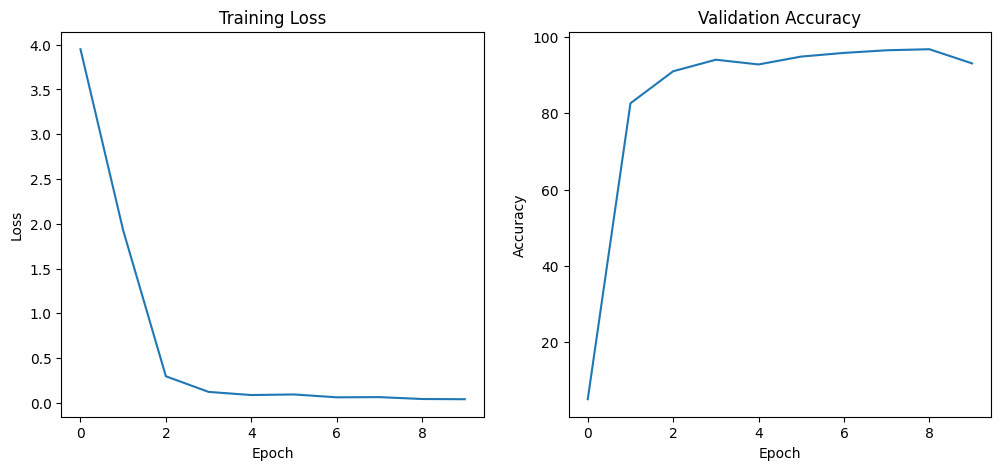

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1,2,2)
plt.plot(val_accuracies)
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving pre_381f5fd1-49d1-4a9d-b01b-4b1e198b5084.jpg to pre_381f5fd1-49d1-4a9d-b01b-4b1e198b5084.jpg


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3254 (\N{KANNADA LETTER SHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


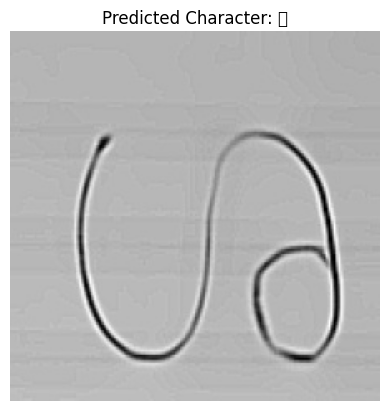

Predicted Tulu Character: ಶ


In [ ]:
class_names = full_dataset.classes

model.eval()

image_path = list(uploaded.keys())[0]

image = Image.open(image_path).convert('RGB')

transform_test = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

input_tensor = transform_test(image).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(input_tensor)
    _, predicted = torch.max(output, 1)

predicted_class = class_names[predicted.item()]

plt.imshow(image)
plt.title(f'Predicted Character: {predicted_class}')
plt.axis('off')
plt.show()

print("Predicted Tulu Character:", predicted_class)

In [ ]:
from google.colab import files
files.download('/content/tulu_convnext_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>